In [ ]:
!python /home/work/yuna/HPA/evaluation/score_humans.py --human_data_dir n20 --with_similarity 
!python /home/work/yuna/HPA/evaluation/score_results.py  --input_dir finetuned  
!python /home/work/yuna/HPA/evaluation/score_results.py  --input_dir pretrained --with_similarity 

In [ ]:
from utils import get_summary

model_results = {} 
model_vqa = get_summary('vqa_1k')  
vqa_5k = get_summary('vqa_5k')   

65


In [ ]:
model_vqa.columns , model_vqa.condition.unique()

(Index(['image_id', 'question_id', 'question_type', 'question', 'answers',
        'multiple_choice_answer', 'answer_type', 'pid', 'output',
        'answer_similarity', 'correct', 'model', 'condition'],
       dtype='object'),
 array(['', 'blind', 'inst blind'], dtype=object))

In [ ]:
df = model_vqa.copy()
df['condition_clean'] = (
    df['condition'].fillna('').astype(str).str.strip().replace({'': 'full'})
)

df_full  = prep(df[df['condition_clean'] == 'full'], 'full')
df_blind = prep(df[df['condition_clean'] == 'blind'], 'blind')
df_inst  = prep(df[df['condition_clean'] == 'inst blind'], 'inst_blind')

merged = (
    df_full
    .merge(df_blind, on=KEYS, how='inner')
    .merge(df_inst,  on=KEYS, how='inner')
)
merged['inst_acc'] = merged['correct_inst_blind'] - merged['correct_blind']
merged['MG'] = merged['correct_full'] - merged['correct_inst_blind']

merged['inst_sim'] = merged['answer_similarity_inst_blind'] - merged['answer_similarity_blind']
merged['MG_sim'] = merged['answer_similarity_full'] - merged['answer_similarity_inst_blind']
merged

,model,question_id,question_type,answer_type,correct_full,answer_similarity_full,correct_blind,answer_similarity_blind,correct_inst_blind,answer_similarity_inst_blind,inst_acc,MG,inst_sim,MG_sim
0,InternVL3_5-1B,189936002,what is the woman,other,33.3,0.940201,0.0,0.342812,0.0,0.342812,0.0,33.3,0.0,0.597389
1,InternVL3_5-1B,498765003,is the man,yes/no,100.0,1.000000,100.0,1.000000,100.0,1.000000,0.0,0.0,0.0,0.000000
2,InternVL3_5-1B,356421011,what is the,other,0.0,0.242588,0.0,0.300234,0.0,0.300234,0.0,0.0,0.0,-0.057646
3,InternVL3_5-1B,14353007,is the,yes/no,100.0,1.000000,66.7,0.733588,66.7,0.733588,0.0,33.3,0.0,0.266413
4,InternVL3_5-1B,170017000,what is the,number,100.0,1.000000,0.0,0.263560,0.0,0.263560,0.0,100.0,0.0,0.736440
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,llava-v1.6-mistral-7b-hf,580621000,what type of,other,100.0,1.000000,100.0,1.000000,100.0,1.000000,0.0,0.0,0.0,0.000000
7996,llava-v1.6-mistral-7b-hf,524577006,what,number,100.0,1.000000,0.0,0.621457,0.0,0.621457,0.0,100.0,0.0,0.378543
7997,llava-v1.6-mistral-7b-hf,283222001,are these,yes/no,100.0,1.000000,0.0,0.733588,0.0,0.733588,0.0,100.0,0.0,0.266413
7998,llava-v1.6-mistral-7b-hf,362229001,are the,yes/no,100.0,1.000000,100.0,1.000000,100.0,1.000000,0.0,0.0,0.0,0.000000


In [380]:

pt = merged.pivot_table( 
    index=['model'], 
    columns=['answer_type'],  # , 'category', 'l2_category' 'condition',  
    values=["correct_full",	"inst_acc",	"MG", ], # 	"inst_sim",	"MG_sim", "answer_similarity_full",	'correct_blind',	"answer_similarity_blind",	"correct_inst_blind",	'answer_similarity_inst_blind',	
    aggfunc=['mean'] # , 'count' 
).round(1) 
pt.dropna(axis=0) 


mean                                         \
                             MG              correct_full                
answer_type              number other yes/no       number other yes/no   
model                                                                    
InternVL3_5-1B             37.7  53.1   25.8         61.5  67.1   91.4   
InternVL3_5-2B             56.0  54.3   27.7         69.1  68.2   92.4   
InternVL3_5-4B             61.5  48.4   30.1         69.7  67.2   94.4   
InternVL3_5-8B             50.5  53.1   30.0         72.4  72.4   95.2   
Qwen3-VL-2B-Instruct       50.5  53.5   30.8         71.0  71.8   94.2   
Qwen3-VL-4B-Instruct       51.9  55.2   29.0         71.9  74.8   94.6   
Qwen3-VL-8B-Instruct       56.8  57.9   29.0         77.6  76.8   96.7   
llava-v1.6-mistral-7b-hf   49.5  59.0   30.5         66.9  77.6   94.3   

                                                
                         inst_acc               
answer_type                number other yes/no  
model                                           
InternVL3_5-1B                5.5  -0.5    0.3  
InternVL3_5-2B               -9.3   1.0   -0.8  
InternVL3_5-4B               -1.6   3.3    1.6  
InternVL3_5-8B               -4.1   0.6    0.4  
Qwen3-VL-2B-Instruct         -2.7   3.2   -2.1  
Qwen3-VL-4B-Instruct          2.7   3.3    2.8  
Qwen3-VL-8B-Instruct          3.3   3.9    2.3  
llava-v1.6-mistral-7b-hf      0.3   1.2    1.0

In [ ]:


# Calculate instruction improvement and model gain (inst_acc, MG) by answer_type, preserving answer type granularity
for atype in pt.columns.levels[2]:
    if atype == '':
        continue
    pt[('inst_acc', '', atype)] = pt[('mean', 'correct', 'inst blind', atype)] - pt[('mean', 'correct', 'blind', atype)]
    pt[('MG', '', atype)] = pt[('mean', 'correct', '', atype)] - pt[('mean', 'correct', 'inst blind', atype)]
pt

mean                      \
                                                  correct                       
condition                                                               blind   
answer_type                                        number other yes/no number   
model                                                                           
InternVL3_5-1B                                       61.5  67.1   91.4   18.3   
InternVL3_5-2B                                       69.1  68.2   92.4   22.4   
InternVL3_5-4B                                       69.7  67.2   94.4    9.8   
InternVL3_5-8B                                       72.4  72.4   95.2   26.0   
InternVL3_5-8B_A1_vqa_gt                             73.8  73.1   95.4    NaN   
InternVL3_5-8B_A2_vqa_10_blind_inst                  72.4  72.4   93.4    NaN   
InternVL3_5-8B_A3_vqa_15_blind_inst                  72.1  72.6   94.1    NaN   
InternVL3_5-8B_A4_mmstar_15_blind_inst               73.5  72.4   95.0    NaN   
Qwen3-4B                                              0.0   7.2   14.6    NaN   
Qwen3-VL-2B-Instruct                                 71.0  71.8   94.2   23.2   
Qwen3-VL-4B-Instruct                                 71.9  74.8   94.6   17.2   
Qwen3-VL-4B-Instruct_A1_vqa_gt                       71.6  76.9   95.7    NaN   
Qwen3-VL-4B-Instruct_A2_vqa_10_blind_inst            71.0  73.9   94.8    NaN   
Qwen3-VL-4B-Instruct_A3_vqa_15_blind_inst            71.6  74.3   94.5    NaN   
Qwen3-VL-4B-Instruct_A4_mmstar_15_blind_inst         72.4  75.4   94.1    NaN   
Qwen3-VL-4B-Instruct_SFT_vqa_15_blind_inst           71.3  74.0   94.8    NaN   
Qwen3-VL-4B-Instruct_SFT_vqa_gt                      68.3  77.2   95.2    NaN   
Qwen3-VL-8B-Instruct                                 77.6  76.8   96.7   17.5   
Qwen3-VL-8B-Instruct_A1_vqa_gt                       76.0  77.1   97.0    NaN   
Qwen3-VL-8B-Instruct_A2_vqa_10_blind_inst            77.6  75.6   96.3    NaN   
Qwen3-VL-8B-Instruct_A3_vqa_15_blind_inst            76.0  77.1   97.0    NaN   
Qwen3-VL-8B-Instruct_A4_mmstar_15_blind_inst         77.3  77.4   96.6    NaN   
Qwen3-VL-8B-Instruct_SFT_mmstar_15_blind_inst        77.3  76.9   96.6    NaN   
Qwen3-VL-8B-Instruct_SFT_vqa_15_blind_inst           77.6  75.7   96.2    NaN   
llava-v1.6-mistral-7b-hf                             66.9  77.6   94.3   17.2   
llava-v1.6-mistral-7b-hf_A1_vqa_gt                   63.4  77.8   93.0    NaN   
llava-v1.6-mistral-7b-hf_A2_vqa_10_blind_inst        64.5  74.5   92.4    NaN   
llava-v1.6-mistral-7b-hf_A4_mmstar_15_blind_inst     66.1  75.7   94.7    NaN   
llava-v1.6-mistral-7b-hf_SFT_mmstar_15_blind_inst    66.4  76.7   94.7    NaN   

                                                                           \
                                                                            
condition                                                      inst blind   
answer_type                                       other yes/no     number   
model                                                                       
InternVL3_5-1B                                     14.5   65.3       23.8   
InternVL3_5-2B                                     12.9   65.4       13.1   
InternVL3_5-4B                                     15.4   62.7        8.2   
InternVL3_5-8B                                     18.8   64.8       21.9   
InternVL3_5-8B_A1_vqa_gt                            NaN    NaN       32.8   
InternVL3_5-8B_A2_vqa_10_blind_inst                 NaN    NaN       32.2   
InternVL3_5-8B_A3_vqa_15_blind_inst                 NaN    NaN       30.3   
InternVL3_5-8B_A4_mmstar_15_blind_inst              NaN    NaN       29.5   
Qwen3-4B                                            NaN    NaN        NaN   
Qwen3-VL-2B-Instruct                               15.1   65.4       20.5   
Qwen3-VL-4B-Instruct                               16.3   62.7       19.9   
Qwen3-VL-4B-Instruct_A1_vqa_gt                      NaN    NaN    

In [ ]:

pt['inst_acc'] = pt[('mean', 'correct', 'inst blind')] - pt[('mean', 'correct', 'blind')]
pt['MG'] = pt[('mean', 'correct', '')] - pt[('mean', 'correct', 'inst blind')] 

pt.columns = ['_'.join([str(i) for i in col if str(i) != '']).strip('_') for col in pt.columns.values]
pt.dropna(axis=0) # 
pt.rename(columns={
    "mean_correct_inst blind": "Blind_inst", 
    "blind": "Delta_inst",
    "mean_correct_blind": "Blind",
    "mean_correct": "GT" 
}, inplace=True)
pt = pt.dropna(subset=['GT', 'MG', 'Blind'], axis=0).dropna(axis=1) 
pt.to_latex(f'./tables/A1_vqa_instruction.tex', float_format="%.1f")
pt 

In [ ]:
### VQA Questions 
human_vqa=pd.read_csv('/home/work/yuna/HPA/evaluation/scored/humans/human_vqa_per_question.csv')
human_vqa['model'] = "humans" 
human_vqa['condition'] = "inst blind" 
human_vqa.rename(columns={"mean_accuracy": 'correct', 'qid': 'question_id'}, inplace=True) 
human_vqa['correct'] = pd.to_numeric(human_vqa['correct'], errors='coerce')
human_vqa['correct'] = (human_vqa['correct'] * 100).round(1) 
qids = human_vqa.question_id.unique()
print(len(qids))

vqa_human_comparison = pd.concat([model_vqa[model_vqa['question_id'].isin(qids)] , human_vqa])
# pt.to_csv(f'./tables/vqa_human_comparison.csv')  

374


In [423]:
human_vqa['subject_similarities']

0      [{'participant_id': '02f952bb_20251210_230336'...
1      [{'participant_id': '02f952bb_20251210_230336'...
2      [{'participant_id': '02f952bb_20251210_230336'...
3      [{'participant_id': '02f952bb_20251210_230336'...
4      [{'participant_id': '02f952bb_20251210_230336'...
                             ...                        
369    [{'participant_id': '02f952bb_20251210_230336'...
370    [{'participant_id': '02f952bb_20251210_230336'...
371    [{'participant_id': '02f952bb_20251210_230336'...
372    [{'participant_id': '02f952bb_20251210_230336'...
373    [{'participant_id': '02f952bb_20251210_230336'...
Name: subject_similarities, Length: 374, dtype: object

In [ ]:
# vqa = vqa_human_comparison.groupby(['model', 'condition']).mean(numeric_only=True)['correct'] 
pt = vqa_human_comparison.pivot_table( 
    index=['model'], 
    columns=['condition'],  # , 'category', 'l2_category' 
    values=['correct'],
    aggfunc=['mean'] # , 'count' 
).round(1)

mean                  inst_acc    MG
                         correct                                
condition                        blind inst blind               
model                                                           
InternVL3_5-1B              80.5  43.6       43.8      0.2  36.7
InternVL3_5-2B              82.1  45.5       45.3     -0.2  36.8
InternVL3_5-4B              83.0  45.0       47.2      2.2  35.8
InternVL3_5-8B              86.9  47.1       45.4     -1.7  41.5
Qwen3-VL-2B-Instruct        83.0  45.5       46.2      0.7  36.8
Qwen3-VL-4B-Instruct        85.9  45.5       47.4      1.9  38.5
Qwen3-VL-8B-Instruct        89.4  44.3       47.4      3.1  42.0
llava-v1.6-mistral-7b-hf    86.3  45.1       46.7      1.6  39.6

In [424]:
import ast
subject_similarities_list = [ast.literal_eval(x) for x in human_vqa["subject_similarities"]]

In [416]:
len(subject_similarities_list)

374

In [412]:
len(sd[pid])

374

In [ ]:
# In progress.ipynb
import sys
sys.path.append('/home/user/HPA/analysis')
from interrater_analysis import *

matrices, avg_matrix = aggregate_subject_matrices(human_vqa, qid_col='question_id')

n = len(responses)
matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        if i == j:
            matrix[i, j] = 1.0  # Perfect agreement with self
        elif similarity_func and metric_type == 'similarity':
            # VQA: semantic similarity
            matrix[i, j] = similarity_func(responses[i], responses[j])
        else:
            # MC: exact match
            matrix[i, j] = 1.0 if responses[i] == responses[j] else 0.0

# Create DataFrame
df = pd.DataFrame(matrix, index=participant_ids, columns=participant_ids) 
avg_matrix

,subject_0,subject_1,subject_10,subject_11,subject_12,subject_13,subject_14,subject_15,subject_16,subject_17,...,subject_21,subject_22,subject_23,subject_3,subject_4,subject_5,subject_6,subject_7,subject_8,subject_9
subject_0,1.000000,0.320856,0.232620,0.275401,0.053476,0.331551,0.320856,0.237968,0.262032,0.283422,...,NaN,NaN,NaN,0.339572,0.237968,0.315508,0.283422,0.302139,0.294118,0.275401
subject_1,0.320856,1.000000,0.342246,0.232620,0.050802,0.368984,0.347594,0.328877,0.371658,0.433155,...,NaN,NaN,NaN,0.513369,0.374332,0.312834,0.296791,0.262032,0.350267,0.433155
subject_10,0.232620,0.342246,1.000000,0.179144,0.082888,0.245989,0.243316,0.229947,0.291444,0.323529,...,NaN,NaN,NaN,0.366310,0.347594,0.283422,0.195187,0.205882,0.270053,0.331551
subject_11,0.275401,0.232620,0.179144,1.000000,0.069519,0.254011,0.262032,0.187166,0.189840,0.205882,...,NaN,NaN,NaN,0.251337,0.184492,0.237968,0.235294,0.280749,0.213904,0.227273
subject_12,0.053476,0.050802,0.082888,0.069519,1.000000,0.042781,0.048128,0.048128,0.104278,0.048128,...,NaN,NaN,NaN,0.053476,0.128342,0.069519,0.042781,0.077540,0.090909,0.064171
subject_13,0.331551,0.368984,0.245989,0.254011,0.042781,1.000000,0.339572,0.229947,0.264706,0.331551,...,NaN,NaN,NaN,0.358289,0.243316,0.302139,0.312834,0.360963,0.267380,0.280749
subject_14,0.320856,0.347594,0.243316,0.262032,0.048128,0.339572,1.000000,0.248663,0.275401,0.294118,...,NaN,NaN,NaN,0.368984,0.240642,0.283422,0.299465,0.344920,0.267380,0.294118
subject_15,0.237968,0.328877,0.229947,0.187166,0.048128,0.229947,0.248663,1.000000,0.259358,0.288770,...,NaN,NaN,NaN,0.347594,0.286096,0.221925,0.219251,0.203209,0.288770,0.288770
subject_16,0.262032,0.371658,0.291444,0.189840,0.104278,0.264706,0.275401,0.259358,1.000000,0.344920,...,NaN,NaN,NaN,0.385027,0.299465,0.291444,0.213904,0.227273,0.286096,0.358289
subject_17,0.283422,0.433155,0.323529,0.205882,0.048128,0.331551,0.294118,0.288770,0.344920,1.000000,...,NaN,NaN,NaN,0.454545,0.382353,0.294118,0.264706,0.235294,0.312834,0.411765


In [ ]:

avg_matrix_reset = avg_matrix.reset_index()
avg_matrix_melted = avg_matrix_reset.melt(id_vars=avg_matrix_reset.columns[0], var_name='subject_j', value_name='agreement')
avg_matrix_melted.rename(columns={avg_matrix_reset.columns[0]: 'subject_i'}, inplace=True)
avg_matrix_melted.dropna(axis=0, inplace=True)

avg_matrix = avg_matrix_melted.pivot(index='subject_i', columns='subject_j', values='agreement') 
plot_subject_matrix_heatmap(avg_matrix, title='Average Inter-Rater Agreement')  

(<Figure size 3000x2400 with 2 Axes>,
 <Axes: title={'center': 'Average Inter-Rater Agreement'}, xlabel='Subject ID', ylabel='Subject ID'>)

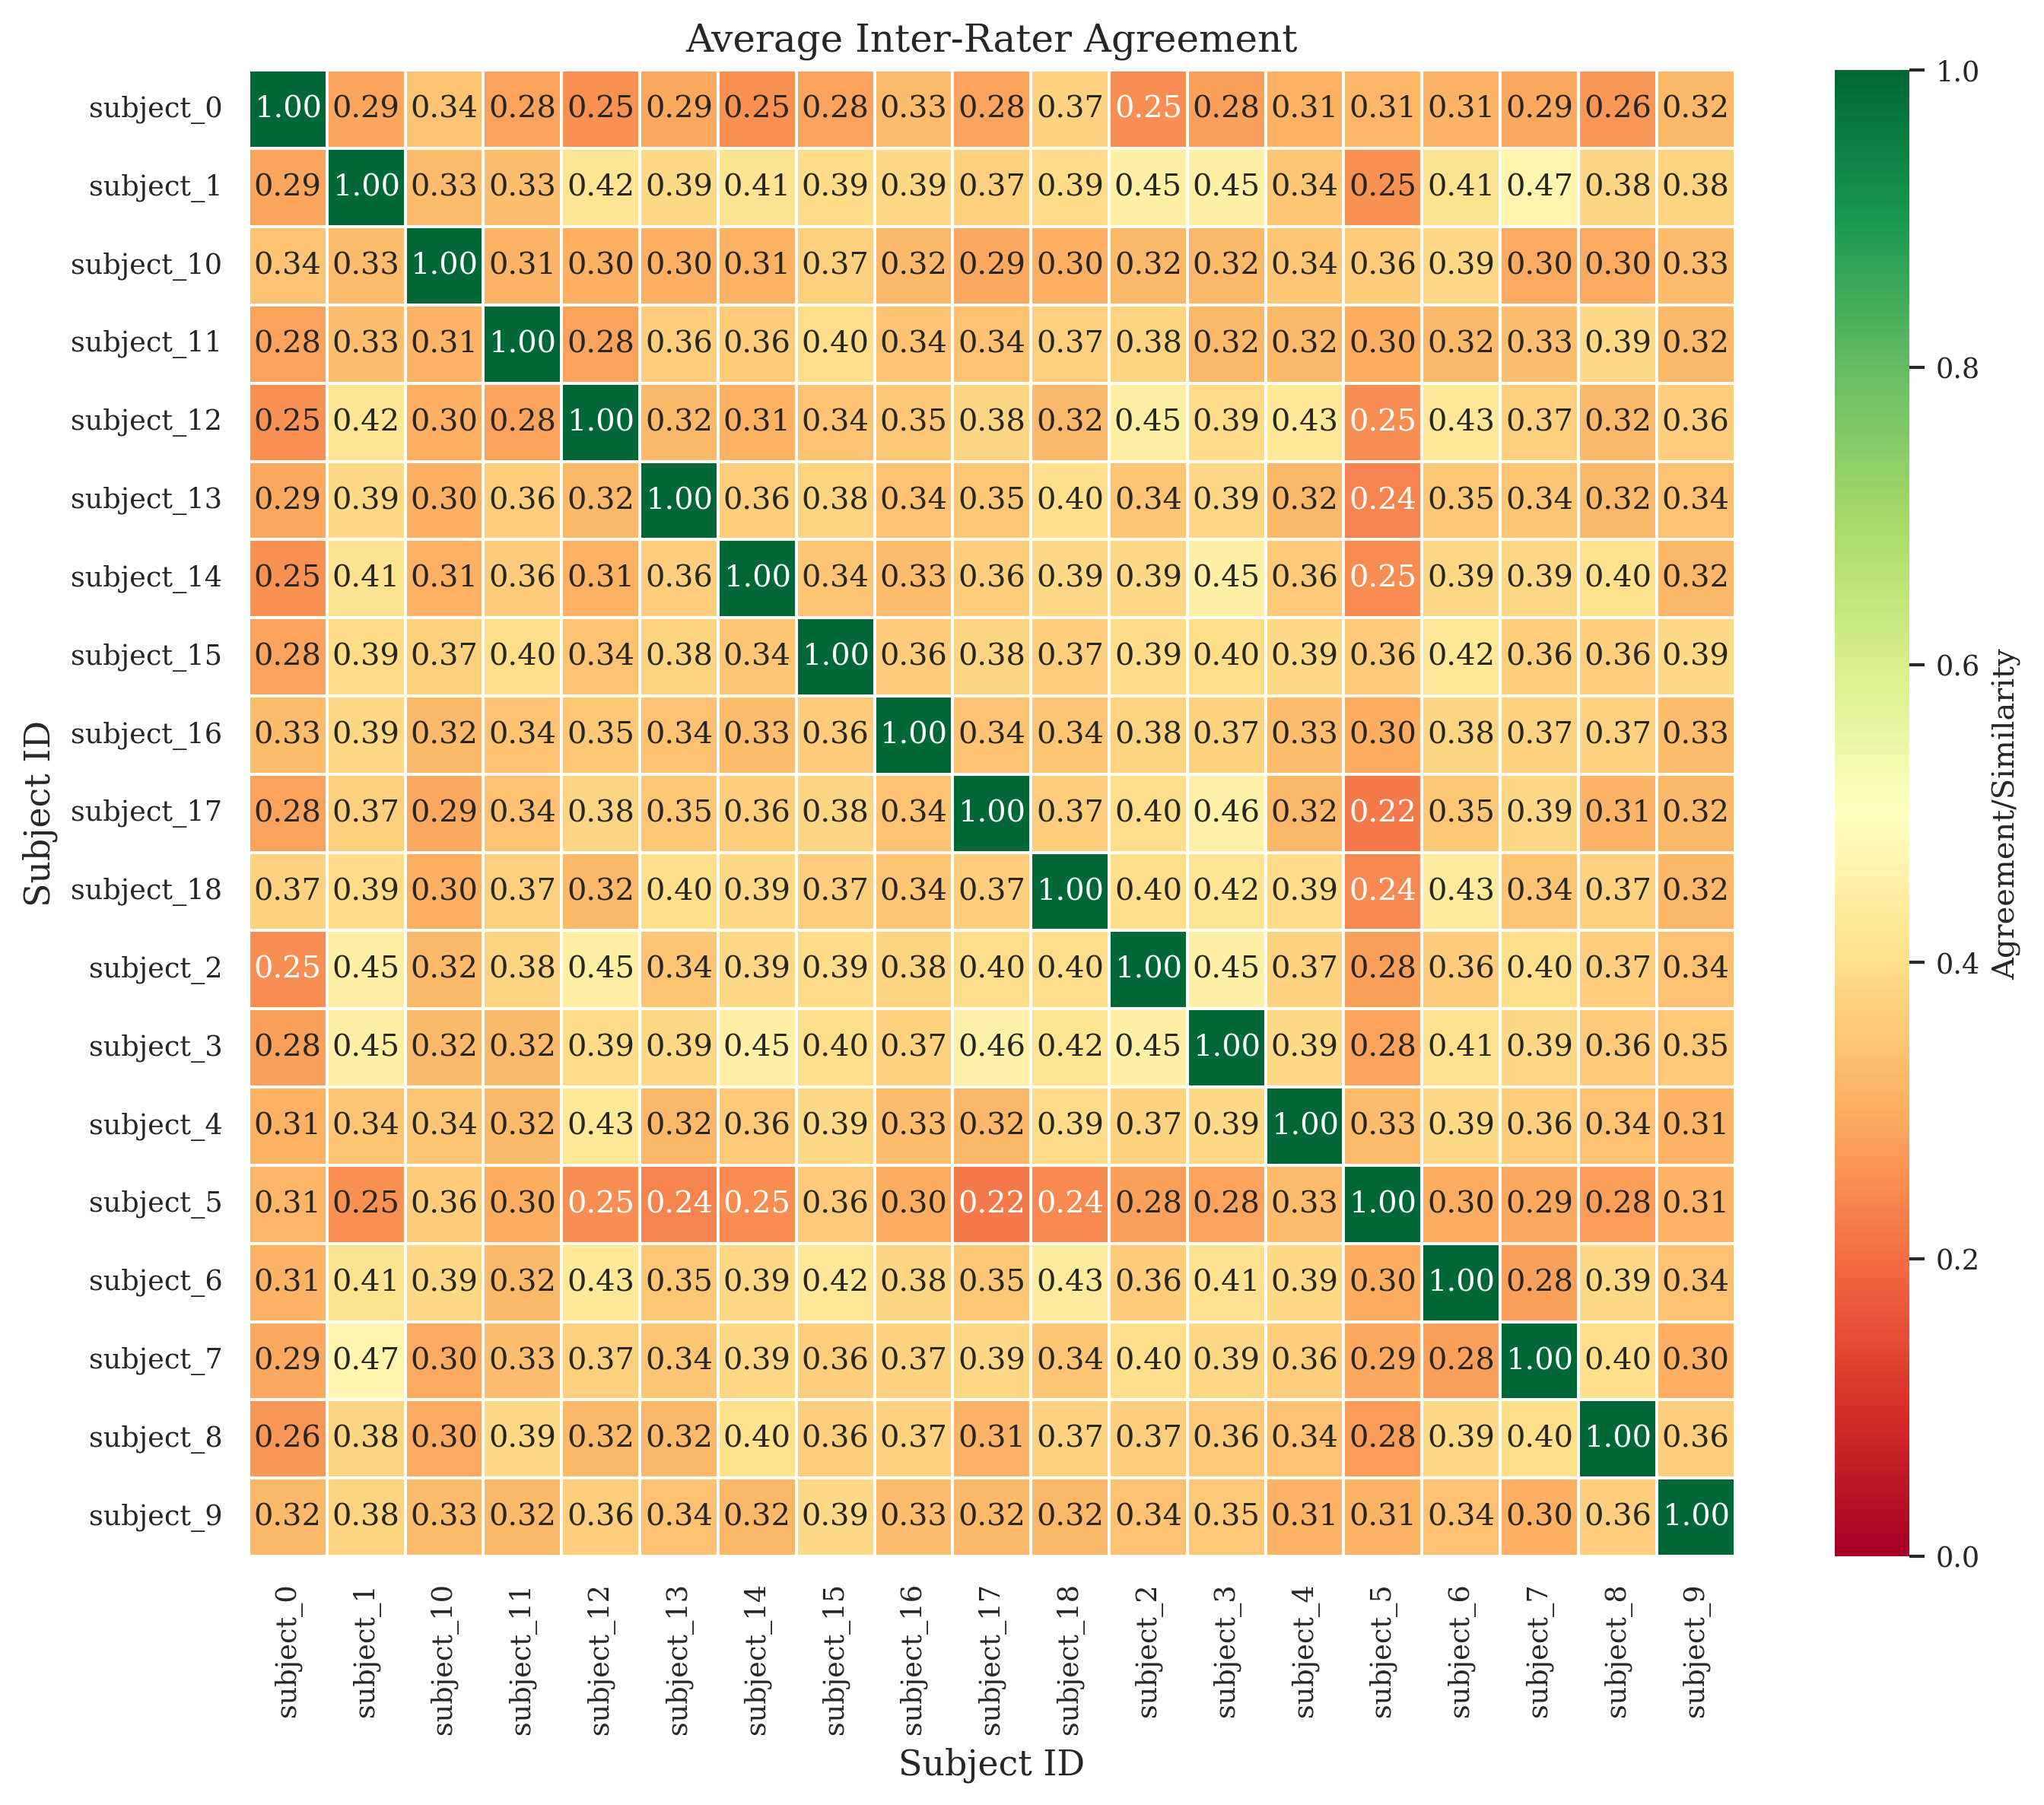

In [258]:
matrices, avg_matrix = aggregate_subject_matrices(human_mc, qid_col='qid')

avg_matrix_reset = avg_matrix.reset_index()
avg_matrix_melted = avg_matrix_reset.melt(id_vars=avg_matrix_reset.columns[0], var_name='subject_j', value_name='agreement')
avg_matrix_melted.rename(columns={avg_matrix_reset.columns[0]: 'subject_i'}, inplace=True)
avg_matrix_melted.dropna(axis=0, inplace=True)

avg_matrix = avg_matrix_melted.pivot(index='subject_i', columns='subject_j', values='agreement') 
plot_subject_matrix_heatmap(avg_matrix, title='Average Inter-Rater Agreement')   

In [ ]:
sns.set_theme(
    style="whitegrid",
    context="paper",
    font="serif"
)

In [ ]:
vqa.dropna(axis=0).to_latex(f'./tables/vqa_human_comparison_pretrained.tex',
    float_format="%.1f")
vqa  

In [ ]:
### MMStar questions 
human_mc=pd.read_csv('/home/work/yuna/HPA/evaluation/scored/humans/human_mc_per_question.csv') 
qids = human_mc.pid.unique() 
human_mc['pid'] = human_mc['pid'].astype('Int64')
print(len(qids))
model_mc = model_results['mmstar']
model_mc['pid'] = model_mc['pid'].astype('Int64') 

pt = model_mc.pivot_table( 
    index=['model', 'pid', 'category', 'l2_category'],  
    columns=['condition'],  
    values=['correct'],
    aggfunc=['mean'] # , 'count' 
)
pt['MG'] = pt[('mean', 'correct', '')] - pt[('mean', 'correct', 'inst blind')] 
pt['inst_acc'] = pt[('mean', 'correct', 'inst blind')] - pt[('mean', 'correct', 'blind')]
pt.to_csv(f'./tables/mmstar_model_MG_by_qid.csv') 
pt.columns = ['_'.join([str(i) for i in col if str(i) != '']).strip('_') for col in pt.columns.values]
pt = pt.reset_index() 
pt = pt.pivot_table( 
    index=['model'], 
    # columns=['category', 'l2_category'],  # 'condition',  
    values=['mean_correct', 'mean_correct_inst blind', 'inst_acc', 'MG'],
    aggfunc=['mean'] # , 'count' 
)  

pt.rename(columns={
    "mean_correct_inst blind": "Blind_inst",
    "inst_acc": "Delta_inst",
    "mean_correct_blind": "Blind",
    "mean_correct": "GT" 
}, inplace=True) 
pt.dropna(axis=0).to_latex(f'./tables/A2_mmstar_mg_inst.tex', float_format="%.1f")   

247


In [ ]:
mmstar_human_comparison = pd.concat([model_mc[model_mc['pid'].isin(qids)], human_mc]) 
pt = mmstar_human_comparison
pt = pt.round(3)
pt.to_csv(f'./tables/mmstar_human_comparison.csv')
with pd.option_context('display.float_format', '{:0.3f}'.format):
    display(pt)   

mean_correct = mmstar_human_comparison.groupby(['model', 'condition'])['correct'].count()
mean_correct.to_latex(f'./tables/mmstar_human_comparison_pretrained.tex', float_format="%.1f")   
 

,index,question,answer,category,l2_category,meta_info,pid,output,extracted_choice,correct,...,confidences,mean_accuracy,std_accuracy,mean_confidence,std_confidence,accuracies,subject_agreements,agreement,human_qid,original_question
0,0,Which option describe the object relationship ...,A,coarse perception,image scene and topic,"{'source': 'MMBench', 'split': 'val', 'image_p...",0,D: The suitcase is beneath the book.,D,0.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,What is the main feature in the background of ...,B,coarse perception,image scene and topic,"{'source': 'SEEDBench_IMG', 'split': 'val', 'i...",1,C: A body of water and the Golden Gate Bridge.,C,0.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,What is the most prominent feature in the imag...,C,coarse perception,image scene and topic,"{'source': 'SEEDBench_IMG', 'split': 'val', 'i...",3,B: The golf course,B,0.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,What is the center of focus in the image?\nOpt...,A,coarse perception,image scene and topic,"{'source': 'SEEDBench_IMG', 'split': 'val', 'i...",4,B: A boy with his head in his hands surrounded...,B,0.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,7,What is the primary subject in this image?\nOp...,D,coarse perception,image scene and topic,"{'source': 'SEEDBench_IMG', 'split': 'val', 'i...",7,B: a man on stage,B,0.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
262,574,What is most prominent in the image?\nOptions:...,A,instance reasoning,single-instance reasoning,"{'source': 'SEEDBench_IMG', 'split': 'val', 'i...",574,C: A boat docked in the water.,NaN,NaN,...,"[0.75, 0.75, 0.5, 0.5, 0.5, 0.5, 1.0, 0.25, 0....",0.250,0.433,0.650,0.242,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, ...",[{'participant_id': '02f952bb_20251210_230336'...,0.232,606.000,What is most prominent in the image?\nOptions:...
263,730,Which special day is associated with this post...,B,instance reasoning,single-instance reasoning,"{'source': 'MMBench', 'split': 'val', 'image_p...",730,The image shows a black background with a whit...,NaN,NaN,...,"[0.5, 1.0, 0.5, 0.25, 0.25, 0.75, 0.05, 0.75, ...",0.350,0.477,0.602,0.295,"[0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, ...",[{'participant_id': '02f952bb_20251210_230336'...,0.400,677.000,Which special day is associated with this post...
264,700,What's the function of the demonstrated object...,B,instance reasoning,single-instance reasoning,"{'source': 'MMBench', 'split': 'val', 'image_p...",700,C: a sanitary facility used for excretion,NaN,NaN,...,"[0.5, 0.5, 0.5, 0.25, 1.0, 0.5, 0.25, 0.75, 0....",0.200,0.400,0.588,0.265,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, ...",[{'participant_id': '02f952bb_20251210_230336'...,0.237,639.000,What's the function of the demonstrated object...
265,289,How many people are performing on the stage?\n...,D,fine-grained perception,recognition,"{'source': 'SEEDBench_IMG', 'split': 'val', 'i...",289,C: One,NaN,NaN,...,"[0.5, 1.0, 0.25, 0.05, 1.0, 0.75, 0.25, 0.75, ...",0.250,0.433,0.640,0.296,"[1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, ...",[{'participant_id': '02f952bb_20251210_230336'...,0.232,342.000,How many people are performing on the stage?\n...


In [ ]:
mmstar_results = analyze_mmstar_by_categories(human_mc, model_mc_agg)
print(mmstar_results['correlation_by_l2_category'])

# 4. Custom analysis
corr_df = correlation_by_metadata(
    model_data, vqa_metadata, 'answer_type',
    x_col='human_accuracy', y_col='model_accuracy'
)


In [ ]:
pt = pt.pivot_table( 
    index=['model'],  
    columns=['category', 'l2_category'],  
    values=['MG'],
    aggfunc=['mean'] # , 'count' 
)
pt.dropna(subset=['mean_correct', 'MG', 'inst_acc'], axis=0).dropna(axis=1) 
pt.columns = ['_'.join([str(i) for i in col if str(i) != '']).strip('_') for col in pt.columns.values] 
pt.round(3).to_csv(f'./tables/mmstar_model_MG_by_category.csv') 

KeyError: 'MG'

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 14,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.linewidth': 1.2,
    'grid.linewidth': 0.5,
    'lines.linewidth': 2,
})

# Optional: Color palette
colors = sns.color_palette("colorblind")

In [ ]:
from scipy.stats import wasserstein_distance, ks_2samp

In [ ]:
def plot_vqa_distributions_with_metrics(H, M, model_name): 

    plt.figure(figsize=(6,4))
    sns.histplot(H, bins=20, kde=True, stat="density",
                 alpha=0.5, label="Human avg")
    sns.histplot(M, bins=20, kde=True, stat="density",
                 alpha=0.5, label="Model")

    plt.xlim(0,1)
    plt.xlabel("VQA score")
    plt.title(
        f"{model_name}\n"
        f"Wasserstein={wd:.3f}, KS={ks:.3f} (p={ks_p:.1e})"
    )
    plt.legend()
    plt.tight_layout()
    # plt.show()
    plt.savefig(f"./figures/distribution_{model_name}", dpi=300)  

    wd = wasserstein_distance(H, M)
    ks, ks_p = ks_2samp(H, M)

    return {
        "wasserstein": wd,
        "ks_stat": ks,
        "ks_p": ks_p,
        "human_mean": H.mean(),
        "model_mean": M.mean(),
    }


In [ ]:
models = vqa_human_comparison.model.unique() 
len(models)

28

In [3]:
pt = vqa_human_comparison.pivot_table(
    index=['model'], 
    columns=['condition'], 
    values=['correct'], # , "mean_confidence" 
    aggfunc=['mean', 'count']
)
pt = pt.round(4)
pt.to_csv(f'./tables/vqa_human_comparison.csv')
pt 

NameError: name 'vqa_human_comparison' is not defined